# Iran Shock & GB Power — Dashboard

Four-panel dashboard mirroring the Tableau Public layout, built in plotly so it can also be served as a static HTML page from GitHub Pages.

**Mental model.** Crude is the signal, gas is the mechanism, cash-out is the amplifier. The hero chart shows Brent (oil signal), TTF (European gas — the mechanism), and GB MID (the downstream effect) on one normalised axis.

**Data flow.** This notebook is pure analysis — it reads from DuckDB views built by `notebooks/05_build_views.ipynb`. To refresh the underlying data, run `uv run iran-shock-ingest-prices` and `uv run iran-shock-ingest-gdelt`, then re-execute notebook 05.

In [1]:
import os
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)

In [2]:
import duckdb
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from iran_shock.config import DUCKDB_PATH

con = duckdb.connect(DUCKDB_PATH, read_only=True)

combined = con.execute("SELECT * FROM v_combined_daily ORDER BY d").df()
events_daily = con.execute("SELECT * FROM v_middle_east_events ORDER BY event_date").df()
impact = con.execute("SELECT * FROM v_event_impact ORDER BY event_date").df()
geo = con.execute("SELECT * FROM v_event_geo").df()
timeline = con.execute("SELECT * FROM timeline ORDER BY event_date").df()

print("v_combined_daily:    ", combined.shape)
print("v_middle_east_events:", events_daily.shape)
print("v_event_impact:      ", impact.shape)
print("v_event_geo:         ", geo.shape)
print("timeline:            ", timeline.shape)

v_combined_daily:     (102, 6)
v_middle_east_events: (150, 5)
v_event_impact:       (15, 11)
v_event_geo:          (75113, 7)
timeline:             (15, 4)


## Panel 1 — Hero: Brent, TTF gas, GB power (% from 1 Feb)

Three series on a single axis, normalised to % change from the first available date. Vertical reference lines mark the 15 curated timeline events. Reading this chart: where the three series move together, the transmission chain is working (Iran shock → crude → gas → power). Where GB power decouples from Brent but tracks TTF, gas-as-marginal-fuel is doing the work.

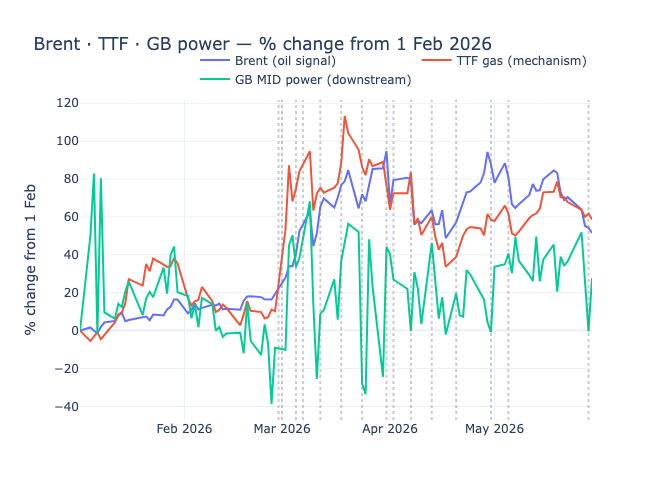

In [3]:
df = combined.copy()
for col in ("brent_close", "ttf_close", "gb_power_avg"):
    first = df[col].dropna().iloc[0]
    df[f"{col}_pct"] = (df[col] / first - 1) * 100

fig = go.Figure()
fig.add_trace(
    go.Scatter(x=df["d"], y=df["brent_close_pct"], name="Brent (oil signal)", line=dict(width=2))
)
fig.add_trace(
    go.Scatter(x=df["d"], y=df["ttf_close_pct"], name="TTF gas (mechanism)", line=dict(width=2))
)
fig.add_trace(
    go.Scatter(
        x=df["d"], y=df["gb_power_avg_pct"], name="GB MID power (downstream)", line=dict(width=2)
    )
)

for _, e in timeline.iterrows():
    fig.add_vline(x=e["event_date"], line_dash="dot", line_color="grey", opacity=0.4)

fig.update_layout(
    title="Brent · TTF · GB power — % change from 1 Feb 2026",
    yaxis_title="% change from 1 Feb",
    xaxis_title="",
    template="plotly_white",
    hovermode="x unified",
    height=500,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig.show()

## Panel 2 — News signal: GDELT daily volume and tone

Daily count of Middle East conflict events (bars) and the mean tone score (line). The pre-war baseline is already 2,000–4,000 events/day across the 12 FIPS countries; the war shock is the *jump above* that baseline. Tone runs persistently negative — read the sign of changes, not the absolute level.

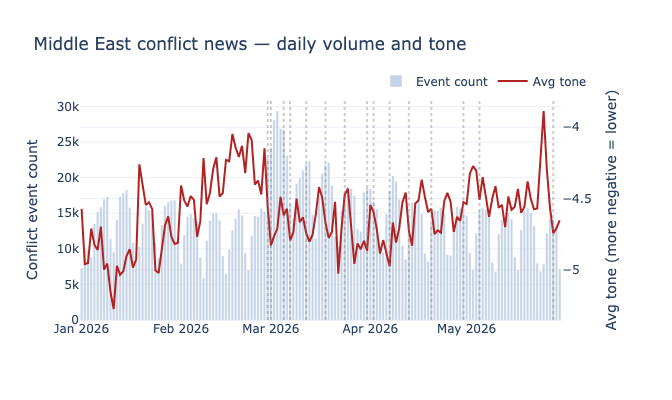

In [4]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Bar(
        x=events_daily["event_date"],
        y=events_daily["event_count"],
        name="Event count",
        marker_color="lightsteelblue",
        opacity=0.75,
    ),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(
        x=events_daily["event_date"],
        y=events_daily["avg_tone"],
        name="Avg tone",
        line=dict(color="firebrick", width=2),
    ),
    secondary_y=True,
)

for _, e in timeline.iterrows():
    fig.add_vline(x=e["event_date"], line_dash="dot", line_color="grey", opacity=0.4)

fig.update_yaxes(title_text="Conflict event count", secondary_y=False)
fig.update_yaxes(title_text="Avg tone (more negative = lower)", secondary_y=True)
fig.update_layout(
    title="Middle East conflict news — daily volume and tone",
    template="plotly_white",
    hovermode="x unified",
    height=400,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig.show()

## Panel 3 — Per-event impact at +3 trading days

For each curated timeline event: Brent, TTF, and GB MID prices on the event day (`t`) and three trading days later (`t+3`), plus the % move. Uses nearest-trading-day lookup so weekend events still produce clean numbers. The three % columns side-by-side are the transmission test — where Brent and TTF moved together with GB power, the chain is visible; where TTF moved but Brent didn't (e.g. Qatar LNG strikes), gas-as-mechanism stands out.

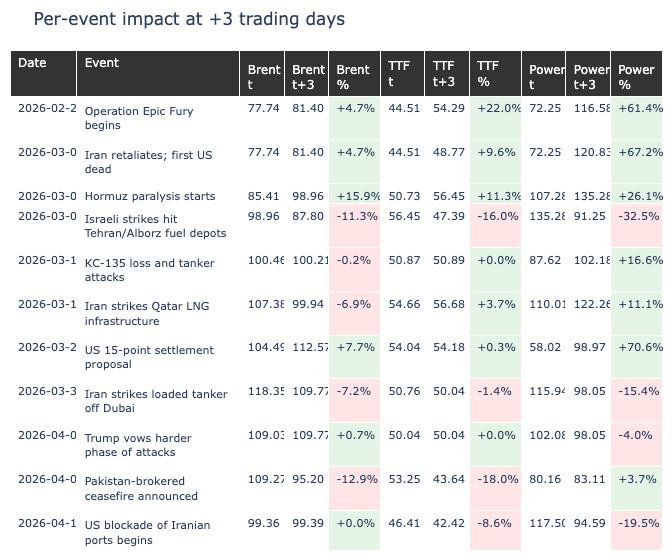

In [5]:
df = impact.copy()


def _fmt_pct(x):
    if pd.isna(x):
        return ""
    return f"{x:+.1f}%"


def _fmt(x, d=2):
    if pd.isna(x):
        return ""
    return f"{x:.{d}f}"


def _pct_colour(x):
    if pd.isna(x):
        return "#f5f5f5"
    return "#ffe5e5" if x < 0 else "#e5f5e5"


brent_colours = [_pct_colour(v) for v in df["brent_pct_3d"]]
ttf_colours = [_pct_colour(v) for v in df["ttf_pct_3d"]]
power_colours = [_pct_colour(v) for v in df["power_pct_3d"]]
neutral = ["white"] * len(df)

fig = go.Figure(
    data=[
        go.Table(
            columnwidth=[90, 220, 60, 60, 70, 60, 60, 70, 60, 60, 70],
            header=dict(
                values=[
                    "Date",
                    "Event",
                    "Brent t",
                    "Brent t+3",
                    "Brent %",
                    "TTF t",
                    "TTF t+3",
                    "TTF %",
                    "Power t",
                    "Power t+3",
                    "Power %",
                ],
                fill_color="#333",
                font=dict(color="white", size=12),
                align="left",
            ),
            cells=dict(
                values=[
                    pd.to_datetime(df["event_date"]).dt.strftime("%Y-%m-%d"),
                    df["label"],
                    df["brent_t"].map(_fmt),
                    df["brent_t3"].map(_fmt),
                    df["brent_pct_3d"].map(_fmt_pct),
                    df["ttf_t"].map(_fmt),
                    df["ttf_t3"].map(_fmt),
                    df["ttf_pct_3d"].map(_fmt_pct),
                    df["power_t"].map(_fmt),
                    df["power_t3"].map(_fmt),
                    df["power_pct_3d"].map(_fmt_pct),
                ],
                fill_color=[
                    neutral,
                    neutral,
                    neutral,
                    neutral,
                    brent_colours,
                    neutral,
                    neutral,
                    ttf_colours,
                    neutral,
                    neutral,
                    power_colours,
                ],
                align="left",
                font=dict(size=11),
            ),
        )
    ]
)
fig.update_layout(
    title="Per-event impact at +3 trading days", height=560, margin=dict(t=50, l=10, r=10, b=10)
)
fig.show()

## Panel 4 — Conflict-event map (Middle East)

Point map from `v_event_geo`. Filtered to city/landmark resolution (`ActionGeo_Type` 3/4) so points sit on real places instead of country centroids. Size by event count, colour by average tone (more red = more negative). Framed on the Middle East.

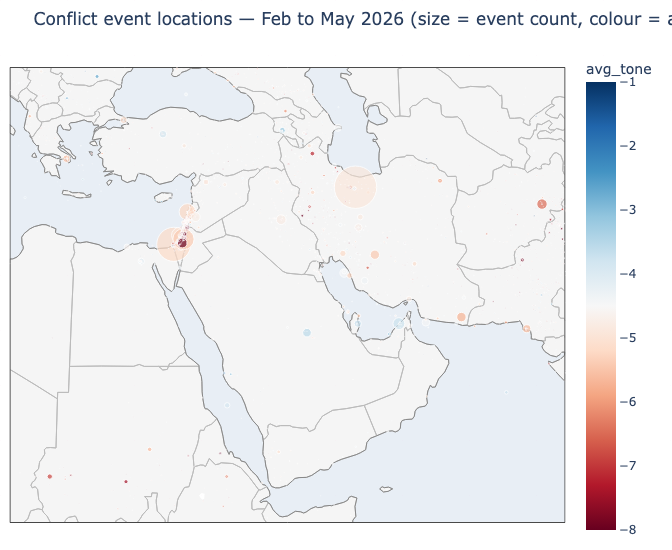

In [6]:
df = geo.copy()
# Drop one-off / noisy single-event places to make the chart legible.
df = df[df["event_count"] >= 5]

fig = px.scatter_geo(
    df,
    lat="lat",
    lon="lon",
    size="event_count",
    size_max=30,
    color="avg_tone",
    color_continuous_scale="RdBu",
    range_color=[-8, -1],
    hover_name="place",
    hover_data={
        "event_count": True,
        "avg_tone": ":.2f",
        "total_mentions": True,
        "lat": False,
        "lon": False,
    },
    projection="natural earth",
    title="Conflict event locations — Feb to May 2026 (size = event count, colour = avg tone)",
)
fig.update_geos(
    lonaxis_range=[20, 70],
    lataxis_range=[10, 45],
    showcountries=True,
    countrycolor="#bbbbbb",
    showcoastlines=True,
    coastlinecolor="#888888",
    showland=True,
    landcolor="#f5f5f5",
    showocean=True,
    oceancolor="#e8eef5",
)
fig.update_layout(height=550, margin=dict(t=50, l=10, r=10, b=10))
fig.show()

## Panel 5 — Robustness statistics

With n=15 (14 usable; the 28 May row has NaN for t+3 because today is 30 May), inferential statistics are suggestive at best. The point of this section is to be honest about which correlations survive a rank-based test, drop a single influential point, or hold up under resampling — and which don't. The headline survivor is the cross-commodity Brent↔TTF result; everything else needs context.

In [7]:
import numpy as np

# Join event-impact with the news metrics on event_date
impact = con.execute('SELECT * FROM v_event_impact ORDER BY event_date').df()
news   = con.execute('SELECT * FROM v_middle_east_events').df()

stats_df = impact.merge(news, on='event_date', how='left')
stats_df = stats_df.dropna(subset=['brent_pct_3d', 'ttf_pct_3d', 'power_pct_3d'])
print(f"n usable events: {len(stats_df)}")
stats_df[['event_date','label','brent_pct_3d','ttf_pct_3d','power_pct_3d',
          'event_count','avg_tone','avg_goldstein']]

n usable events: 14


,event_date,label,brent_pct_3d,ttf_pct_3d,power_pct_3d,event_count,avg_tone,avg_goldstein
0,2026-02-28,Operation Epic Fury begins,4.7,22.0,61.4,22754,-4.557167,-6.382236
1,2026-03-01,Iran retaliates; first US dead,4.7,9.6,67.2,24257,-4.828647,-6.701608
2,2026-03-05,Hormuz paralysis starts,15.9,11.3,26.1,26764,-4.618060,-6.155463
3,2026-03-07,Israeli strikes hit Tehran/Alborz fuel depots,-11.3,-16.0,-32.5,16414,-4.793029,-6.478799
4,2026-03-12,KC-135 loss and tanker attacks,-0.2,0.0,16.6,21902,-4.742384,-6.216889
5,2026-03-18,Iran strikes Qatar LNG infrastructure,-6.9,3.7,11.1,21840,-4.668429,-6.228530
6,2026-03-24,US 15-point settlement proposal,7.7,0.3,70.6,18138,-4.473392,-6.080637
7,2026-03-31,Iran strikes loaded tanker off Dubai,-7.2,-1.4,-15.4,18581,-4.864865,-6.060847
8,2026-04-02,Trump vows harder phase of attacks,0.7,0.0,-4.0,16723,-4.595288,-5.843365
9,2026-04-07,Pakistan-brokered ceasefire announced,-12.9,-18.0,3.7,18130,-4.975196,-5.983486


### Pearson vs Spearman correlations

Pearson assumes linear relationships and is sensitive to outliers; Spearman is rank-based and robust. If a result holds in both, it's real signal. If only Pearson is significant, treat it as outlier-driven.

In [8]:
cols = ['brent_pct_3d','ttf_pct_3d','power_pct_3d','event_count','avg_tone','avg_goldstein']
print('Pearson r:')
print(stats_df[cols].corr(method='pearson').round(2))
print()
print('Spearman ρ (rank-based, robust to outliers):')
print(stats_df[cols].corr(method='spearman').round(2))

Pearson r:
               brent_pct_3d  ttf_pct_3d  power_pct_3d  event_count  avg_tone  \
brent_pct_3d           1.00        0.75          0.59         0.34      0.53   
ttf_pct_3d             0.75        1.00          0.67         0.49      0.50   
power_pct_3d           0.59        0.67          1.00         0.50      0.37   
event_count            0.34        0.49          0.50         1.00     -0.16   
avg_tone               0.53        0.50          0.37        -0.16      1.00   
avg_goldstein         -0.06       -0.28         -0.36        -0.66      0.30   

               avg_goldstein  
brent_pct_3d           -0.06  
ttf_pct_3d             -0.28  
power_pct_3d           -0.36  
event_count            -0.66  
avg_tone                0.30  
avg_goldstein           1.00  

Spearman ρ (rank-based, robust to outliers):
               brent_pct_3d  ttf_pct_3d  power_pct_3d  event_count  avg_tone  \
brent_pct_3d           1.00        0.83          0.62         0.23      0.48   
ttf_p

### Bootstrap CI on the headline result (Brent↔TTF)

Brent↔TTF was the only correlation with real statistical power in the previous analysis (r ≈ +0.75, p ≈ 0.002). Bootstrap resampling tells us how stable it is at this sample size — narrow CI means the result is robust to sampling variation; wide CI means it could just as easily be much weaker.

In [9]:
rng = np.random.default_rng(42)
n_boot = 5000
n = len(stats_df)
brent = stats_df['brent_pct_3d'].values
ttf   = stats_df['ttf_pct_3d'].values

r_obs = float(np.corrcoef(brent, ttf)[0, 1])
boot_rs = []
for _ in range(n_boot):
    idx = rng.choice(n, n, replace=True)
    if np.std(brent[idx]) > 0 and np.std(ttf[idx]) > 0:
        boot_rs.append(np.corrcoef(brent[idx], ttf[idx])[0, 1])
boot_rs = np.array(boot_rs)

print(f'Brent↔TTF Pearson r (observed): {r_obs:+.3f}')
print(f'Bootstrap 95% CI:                [{np.percentile(boot_rs, 2.5):+.3f}, {np.percentile(boot_rs, 97.5):+.3f}]')
print(f'P(r > 0):                        {(boot_rs > 0).mean() * 100:.1f}%')
print(f'P(r > 0.5):                      {(boot_rs > 0.5).mean() * 100:.1f}%')

Brent↔TTF Pearson r (observed): +0.747
Bootstrap 95% CI:                [+0.483, +0.914]
P(r > 0):                        100.0%
P(r > 0.5):                      97.0%


### Leave-one-out

Drop each row in turn, recompute the correlation, and report the full-sample value plus the min/max across the 14 leave-one-out samples. If the min and max bracket zero, a single point is driving the result and the correlation isn't real. A `⚠` flag in the last column means the sign of the correlation flipped under at least one drop.

In [10]:
pairs = [
    ('brent_pct_3d', 'ttf_pct_3d'),
    ('ttf_pct_3d',   'power_pct_3d'),
    ('brent_pct_3d', 'power_pct_3d'),
    ('avg_tone',     'brent_pct_3d'),
    ('avg_tone',     'ttf_pct_3d'),
    ('avg_tone',     'power_pct_3d'),
    ('avg_goldstein','power_pct_3d'),
    ('event_count',  'ttf_pct_3d'),
]

print(f"{'pair':<35} {'full':>7} {'min LOO':>9} {'max LOO':>9} {'flag':>6}")
print('-' * 70)
for a, b in pairs:
    full = float(stats_df[a].corr(stats_df[b]))
    loo = []
    for i in stats_df.index:
        sub = stats_df.drop(i)
        loo.append(float(sub[a].corr(sub[b])))
    sign_flip = (np.sign(min(loo)) != np.sign(full)) or (np.sign(max(loo)) != np.sign(full))
    flag = '⚠' if sign_flip else ''
    print(f"{a + ' ↔ ' + b:<35} {full:>+7.2f} {min(loo):>+9.2f} {max(loo):>+9.2f} {flag:>6}")

pair                                   full   min LOO   max LOO   flag
----------------------------------------------------------------------
brent_pct_3d ↔ ttf_pct_3d             +0.75     +0.68     +0.80       
ttf_pct_3d ↔ power_pct_3d             +0.67     +0.59     +0.78       
brent_pct_3d ↔ power_pct_3d           +0.59     +0.51     +0.65       
avg_tone ↔ brent_pct_3d               +0.53     +0.38     +0.67       
avg_tone ↔ ttf_pct_3d                 +0.50     +0.30     +0.61       
avg_tone ↔ power_pct_3d               +0.37     +0.23     +0.59       
avg_goldstein ↔ power_pct_3d          -0.36     -0.63     -0.13       
event_count ↔ ttf_pct_3d              +0.49     +0.42     +0.65       


### Multi-horizon persistence (t+1, t+3, t+5, t+10)

Reads from `v_event_impact_multi`. Mean across all events at each horizon, per series. The interpretation:
- **Brent rising through to t+10** → real supply-destruction repricing (PDF phase 2), not just sentiment.
- **TTF rising through to t+10** → gas channel sustained; transmission story intact at horizon.
- **Power dispersion across horizons** → coverage / weekend-anchoring noise that the v1 design choices can't fully suppress.

In [11]:
multi = con.execute('SELECT * FROM v_event_impact_multi ORDER BY event_date').df()
# drop the last event where t+10 isn't yet realised
multi = multi.dropna(subset=['brent_pct_10d'])
print(f'n events with full t+10 horizon: {len(multi)}')
print()
horizons = ['1d', '3d', '5d', '10d']
out = pd.DataFrame({
    'horizon':       horizons,
    'brent_mean':   [multi[f'brent_pct_{h}'].mean()   for h in horizons],
    'brent_median': [multi[f'brent_pct_{h}'].median() for h in horizons],
    'ttf_mean':     [multi[f'ttf_pct_{h}'].mean()     for h in horizons],
    'ttf_median':   [multi[f'ttf_pct_{h}'].median()   for h in horizons],
    'power_mean':   [multi[f'power_pct_{h}'].mean()   for h in horizons],
    'power_median': [multi[f'power_pct_{h}'].median() for h in horizons],
}).round(1)
print(out.to_string(index=False))

n events with full t+10 horizon: 14

horizon  brent_mean  brent_median  ttf_mean  ttf_median  power_mean  power_median
     1d        -2.2           0.0      -1.2        -0.2         2.3           0.0
     3d        -0.2           0.2       0.9         0.2        16.3          10.7
     5d         1.6           0.8       1.0         1.4         6.5          -1.7
    10d         2.3           4.8      -1.2         0.3         1.3          -3.6


## Panel 6 — Conditional-transmission test (gas-as-marginal-fuel)

The gas-as-marginal-fuel hypothesis (per `00_findings.md`): Brent / TTF → GB power transmission is **conditional** on gas being the marginal fuel that day. When wind is high and gas is crowded down the merit order, GB power decouples from European gas. When demand is high and gas is at the margin, GB power tracks TTF tightly.

Test design: bucket the 14 usable timeline events by GB gas-share on event day (`high_gas` ≥ 30% vs `low_gas` < 30%, splitting near the 150-day median of 34.7%). Compare within-regime correlations between TTF and GB power.

Source: Elexon BMRS `/datasets/FUELHH` aggregated to daily gas share (`v_gb_gen_mix_daily`); the regime-tagged event impacts in `v_event_impact_regime`.

In [12]:
# Gas-share distribution across the full 150-day window — sanity check the threshold
mix = con.execute('SELECT * FROM v_gb_gen_mix_daily ORDER BY price_date').df()
print('Daily gas share of GB transmission-connected generation (n=150 days):')
print(mix[['gas_share_pct','renewables_share_pct','nuclear_share_pct']].describe().round(1))


Daily gas share of GB transmission-connected generation (n=150 days):
       gas_share_pct  renewables_share_pct  nuclear_share_pct
count          150.0                 150.0              150.0
mean            34.1                  39.3               17.2
std             13.7                  15.2                5.7
min              8.6                  10.6               10.0
25%             22.1                  26.9               12.8
50%             34.7                  39.4               15.8
75%             45.2                  52.3               20.2
max             62.4                  68.9               35.2


In [13]:
# Regime view: each event tagged with gas share on event-day and bucketed
regime_df = con.execute('SELECT * FROM v_event_impact_regime ORDER BY event_date').df()
regime_clean = regime_df.dropna(subset=['power_pct_3d','brent_pct_3d','ttf_pct_3d']).copy()
print(f'n usable events: {len(regime_clean)}')
regime_clean[['event_date','label','gas_share_pct','regime','brent_pct_3d','ttf_pct_3d','power_pct_3d']]

n usable events: 14


,event_date,label,gas_share_pct,regime,brent_pct_3d,ttf_pct_3d,power_pct_3d
0,2026-02-28,Operation Epic Fury begins,23.3,low_gas,4.7,22.0,61.4
1,2026-03-01,Iran retaliates; first US dead,23.3,low_gas,4.7,9.6,67.2
2,2026-03-05,Hormuz paralysis starts,35.8,high_gas,15.9,11.3,26.1
3,2026-03-07,Israeli strikes hit Tehran/Alborz fuel depots,58.7,high_gas,-11.3,-16.0,-32.5
4,2026-03-12,KC-135 loss and tanker attacks,16.7,low_gas,-0.2,0.0,16.6
5,2026-03-18,Iran strikes Qatar LNG infrastructure,38.5,high_gas,-6.9,3.7,11.1
6,2026-03-24,US 15-point settlement proposal,12.7,low_gas,7.7,0.3,70.6
7,2026-03-31,Iran strikes loaded tanker off Dubai,40.9,high_gas,-7.2,-1.4,-15.4
8,2026-04-02,Trump vows harder phase of attacks,35.8,high_gas,0.7,0.0,-4.0
9,2026-04-07,Pakistan-brokered ceasefire announced,13.5,low_gas,-12.9,-18.0,3.7


### Mean impact by regime

Power moves are large on **low-gas** events (mean +42.6%) but coupled to gas/oil on **high-gas** events (small means, in line with TTF/Brent). Two effects compose: on low-gas days the gas channel is muted, so power moves on independent drivers (base-rate, wind, weekend coverage); on high-gas days power moves in sync with gas/oil but the gas/oil moves themselves were smaller in this window.

In [14]:
agg = regime_clean.groupby('regime').agg(
    n=('label','count'),
    gas_share_mean=('gas_share_pct','mean'),
    brent_mean=('brent_pct_3d','mean'),
    brent_median=('brent_pct_3d','median'),
    ttf_mean=('ttf_pct_3d','mean'),
    ttf_median=('ttf_pct_3d','median'),
    power_mean=('power_pct_3d','mean'),
    power_median=('power_pct_3d','median'),
).round(1)
print(agg.to_string())

          n  gas_share_mean  brent_mean  brent_median  ttf_mean  ttf_median  power_mean  power_median
regime                                                                                               
high_gas  8            42.9        -0.8          -3.4      -0.8        -0.7        -3.3          -3.4
low_gas   6            16.5         0.7           2.6       3.1         2.5        42.6          48.8


### Within-regime correlations — the headline mechanistic result

On **high-gas days**, TTF↔power tightens to ρ = +0.90 (Pearson +0.92) — near-perfect rank correlation. On **low-gas days** the same pair drops to ρ = +0.60. That's the gas-as-marginal-fuel mechanism visible in the data: when gas sets the GB merit order, European gas prices flow directly into GB power; when wind/nuclear push gas out of the stack, the transmission loosens.

Brent↔TTF is stable across regimes (cross-commodity coupling doesn't depend on the GB stack — it's set in global LNG/oil markets). The high low-gas Brent↔power (+0.99) sits on n=6 with one outlier and shouldn't be taken at face value.

In [15]:
for regime in ('high_gas', 'low_gas'):
    sub = regime_clean[regime_clean['regime'] == regime]
    n = len(sub)
    print(f'\n{regime}  (n={n}, mean gas share {sub["gas_share_pct"].mean():.1f}%):')
    pairs = [('brent_pct_3d','ttf_pct_3d'), ('ttf_pct_3d','power_pct_3d'), ('brent_pct_3d','power_pct_3d')]
    for a, b in pairs:
        r_p = sub[a].corr(sub[b], method='pearson')
        r_s = sub[a].corr(sub[b], method='spearman')
        print(f'  {a:<14} ↔ {b:<14}  Pearson r={r_p:+.2f}  Spearman ρ={r_s:+.2f}')


high_gas  (n=8, mean gas share 42.9%):
  brent_pct_3d   ↔ ttf_pct_3d      Pearson r=+0.79  Spearman ρ=+0.81
  ttf_pct_3d     ↔ power_pct_3d    Pearson r=+0.92  Spearman ρ=+0.90
  brent_pct_3d   ↔ power_pct_3d    Pearson r=+0.72  Spearman ρ=+0.62

low_gas  (n=6, mean gas share 16.5%):
  brent_pct_3d   ↔ ttf_pct_3d      Pearson r=+0.77  Spearman ρ=+0.64
  ttf_pct_3d     ↔ power_pct_3d    Pearson r=+0.72  Spearman ρ=+0.60
  brent_pct_3d   ↔ power_pct_3d    Pearson r=+0.90  Spearman ρ=+0.99


### gas_share_pct as a continuous regressor

Same idea but without bucketing: how does each side of the transmission chain correlate with gas share on event day?

In [16]:
print(f'Correlation between event-day gas share and +3d moves (n={len(regime_clean)}):')
for col in ('brent_pct_3d', 'ttf_pct_3d', 'power_pct_3d'):
    r_p = regime_clean['gas_share_pct'].corr(regime_clean[col], method='pearson')
    r_s = regime_clean['gas_share_pct'].corr(regime_clean[col], method='spearman')
    print(f'  gas_share ↔ {col:<14}  Pearson r={r_p:+.2f}  Spearman ρ={r_s:+.2f}')

Correlation between event-day gas share and +3d moves (n=14):
  gas_share ↔ brent_pct_3d    Pearson r=-0.25  Spearman ρ=-0.33
  gas_share ↔ ttf_pct_3d      Pearson r=-0.28  Spearman ρ=-0.36
  gas_share ↔ power_pct_3d    Pearson r=-0.73  Spearman ρ=-0.78


### Visualising the regime split

Scatter of TTF +3d vs power +3d, coloured by regime. A clean separation by colour validates the mechanistic story visually.

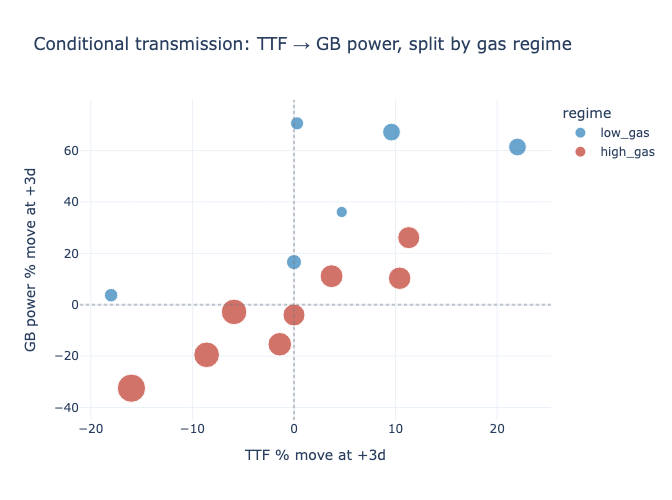

In [17]:
fig = px.scatter(
    regime_clean,
    x='ttf_pct_3d', y='power_pct_3d',
    color='regime',
    size='gas_share_pct',
    hover_name='label',
    hover_data={'event_date': True, 'gas_share_pct': ':.1f', 'ttf_pct_3d': False, 'power_pct_3d': False},
    color_discrete_map={'high_gas': '#c0392b', 'low_gas': '#2c7fb8'},
    labels={'ttf_pct_3d': 'TTF % move at +3d', 'power_pct_3d': 'GB power % move at +3d'},
    title='Conditional transmission: TTF → GB power, split by gas regime',
)
fig.update_layout(template='plotly_white', height=500)
# zero lines
fig.add_hline(y=0, line_dash='dot', line_color='grey', opacity=0.4)
fig.add_vline(x=0, line_dash='dot', line_color='grey', opacity=0.4)
fig.show()

## Export to static HTML (for GitHub Pages)

Optional: write the rendered notebook to a single HTML file under `docs-site/`. A GHA workflow can re-execute this notebook on a `schedule:` cron and publish the output to GitHub Pages. See `docs/22_migrate_to_aws.md` for the workflow YAML.

In [ ]:
# To export: from the project root, run
#   uv run jupyter nbconvert --execute notebooks/06_dashboard.ipynb \
#       --to html --output-dir docs-site/
# Then commit docs-site/06_dashboard.html for GitHub Pages.